# Acrobot-v1 — DPO vs PPO-RLHF

**Task**: Compare DPO and PPO-RLHF for different preference dataset sizes K ∈ {50, 100, 200, 500}, averaged over 3 seeds.

**Structure**
1. Imports & seeding
2. Policy network (shared actor-critic)
3. REINFORCE training utilities
4. Two-phase training: saves $\pi_2$ (intermediate) and $\pi_1$ (expert)
5. Preference dataset generation
6. DPO training
7. PPO-RLHF (reward model + PPO with KL penalty)
8. Full experiment loop (skips retraining if files exist)
9. $\beta$ sweep for DPO
10. Combined poster figure (A–D)

## 1 · Imports & seeding

In [53]:
import os, copy, math, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from tqdm import tqdm
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker
from matplotlib.lines import Line2D
from PIL import Image

CHECKPOINT_DIR = "checkpoints_acrobot"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 2 · Policy network

In [54]:
class Policy(nn.Module):
    """Shared actor-critic network."""
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
        )
        self.actor  = nn.Linear(128, act_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, obs):
        h = self.net(obs)
        return self.actor(h), self.critic(h)

## 3 · REINFORCE training utilities

In [55]:
def choose_action(policy, obs):
    obs_t = torch.tensor(obs, dtype=torch.float32)
    logits, value = policy(obs_t)
    dist   = Categorical(logits=logits)
    action = dist.sample()
    return action.item(), dist.log_prob(action), value.squeeze()

def rollout(env, policy, max_steps=500):
    obs, _ = env.reset()
    traj   = {"obs": [], "actions": [], "rewards": [],
              "log_probs": [], "values": [], "total_reward": 0.0}
    policy.train()
    for _ in range(max_steps):
        a, lp, v = choose_action(policy, obs)
        nobs, r, term, trunc, _ = env.step(a)
        traj["obs"].append(obs); traj["actions"].append(a)
        traj["rewards"].append(r); traj["log_probs"].append(lp)
        traj["values"].append(v); traj["total_reward"] += r
        obs = nobs
        if term or trunc: break
    return traj

def compute_returns(rewards, gamma=0.99):
    G, returns = 0, []
    for r in reversed(rewards):
        G = r + gamma * G; returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)

def update_policy(policy, optimizer, traj, gamma=0.99):
    returns    = compute_returns(traj["rewards"], gamma)
    log_probs  = torch.stack(traj["log_probs"])
    values     = torch.stack(traj["values"])
    returns    = (returns - returns.mean()) / (returns.std() + 1e-8)
    advantages = returns - values.detach()
    loss = -(log_probs * advantages).sum() + ((returns - values) ** 2).sum()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    return loss.item()

def evaluate_policy(policy, env_name="Acrobot-v1", episodes=50,
                    max_steps=500, base_seed=None):
    env = gym.make(env_name)
    rewards = []
    policy.eval()
    for ep in range(episodes):
        obs, _ = env.reset(seed=None if base_seed is None else base_seed + ep)
        total, done = 0.0, False
        for _ in range(max_steps):
            with torch.no_grad():
                logits, _ = policy(torch.tensor(obs, dtype=torch.float32))
            obs, r, term, trunc, _ = env.step(torch.argmax(logits).item())
            total += r; done = term or trunc
            if done: break
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards), np.array(rewards)

## 4 · Two-phase training: $\pi_2$ (intermediate) and $\pi_1$ (expert)

- **Phase 1** — evaluates every 10 steps; saves the checkpoint the first time eval crosses `pi2_target` as π₂.
- **Phase 2** — evaluates every 50 steps; keeps the best checkpoint as π₁; stops when `pi1_target` is reached.

In [56]:
def train_two_phase(seed=0, lr=3e-4, gamma=0.99,
                    pi2_target=-200, pi1_target=-80,
                    max_steps=20000, env_name="Acrobot-v1",
                    save_pi1=None, save_pi2=None):
    set_seed(seed)
    env     = gym.make(env_name)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n
    policy    = Policy(obs_dim, act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    pi2_saved, best_eval = False, -float("inf")
    pbar = tqdm(range(max_steps), desc=f"Two-phase seed={seed}")
    for step in pbar:
        update_policy(policy, optimizer, rollout(env, policy))
        every = 10 if not pi2_saved else 50
        eps   = 20 if not pi2_saved else 10
        if step % every == 0 and step > 0:
            m, s, _ = evaluate_policy(policy, env_name, eps,
                                      base_seed=seed * 100000 + step)
            if not pi2_saved and m >= pi2_target:
                torch.save({"model_state": copy.deepcopy(policy.state_dict()),
                            "obs_dim": obs_dim, "act_dim": act_dim,
                            "eval_mean_reward": m, "step": step, "seed": seed},
                           save_pi2)
                pi2_saved = True
                print(f"\n  π₂ saved @ step {step}: eval={m:.1f}")
            if pi2_saved and m > best_eval:
                best_eval = m
                torch.save({"model_state": copy.deepcopy(policy.state_dict()),
                            "obs_dim": obs_dim, "act_dim": act_dim,
                            "eval_mean_reward": m, "step": step, "seed": seed},
                           save_pi1)
            pbar.set_postfix({"eval": f"{m:.0f}", "best_π1": f"{best_eval:.0f}",
                              "phase": "2" if pi2_saved else "1"})
            if pi2_saved and best_eval >= pi1_target:
                print(f"\n  π₁ done @ step {step}: best={best_eval:.1f}"); break
    env.close()

## 5 · Checkpoint loading

In [57]:
def load_checkpoint(path):
    ck  = torch.load(path, map_location="cpu", weights_only=False)
    pol = Policy(ck["obs_dim"], ck["act_dim"])
    pol.load_state_dict(ck["model_state"])
    pol.eval()
    return pol

def load_state_dict_pol(path):
    """Load a bare state-dict checkpoint (DPO / PPO output)."""
    state = torch.load(path, map_location="cpu", weights_only=False)
    pol   = Policy(6, 3)          # Acrobot: obs_dim=6, act_dim=3
    pol.load_state_dict(state)
    pol.eval()
    return pol

## 6 · Preference dataset generation

In [58]:
def rollout_for_prefs(env, policy, max_steps=500,
                      deterministic=True, seed=None):
    obs, _ = env.reset() if seed is None else env.reset(seed=seed)
    traj, total = [], 0.0
    policy.eval()
    for _ in range(max_steps):
        with torch.no_grad():
            logits, _ = policy(torch.tensor(obs, dtype=torch.float32))
        a = (torch.argmax(logits) if deterministic
             else Categorical(logits=logits).sample()).item()
        nobs, r, term, trunc, _ = env.step(a)
        traj.append((obs, a, r)); total += r; obs = nobs
        if term or trunc: break
    return traj, total

def generate_preferences(env_name, pi1, pi2, K=200, base_seed=None):
    """Bradley-Terry labeling: P(τ₁ ≻ τ₂) = σ(r₁ - r₂), no temperature."""
    env     = gym.make(env_name)
    dataset = []
    for i in tqdm(range(K), desc="Generating preferences", leave=False):
        s1 = None if base_seed is None else base_seed + 2 * i
        s2 = None if base_seed is None else base_seed + 2 * i + 1
        t1, r1 = rollout_for_prefs(env, pi1, seed=s1)
        t2, r2 = rollout_for_prefs(env, pi2, seed=s2)
        p = 1.0 / (1.0 + np.exp(r2 - r1))   # σ(r1 - r2)
        if np.random.rand() < p:
            dataset.append((t1, t2))
        else:
            dataset.append((t2, t1))
    env.close()
    return dataset

## 7 · DPO training

In [59]:
def log_prob_traj(policy, traj, device="cpu"):
    obs     = torch.tensor([s[0] for s in traj], dtype=torch.float32, device=device)
    actions = torch.tensor([s[1] for s in traj], dtype=torch.long,    device=device)
    logits, _ = policy(obs)
    lp = F.log_softmax(logits, dim=-1).gather(1, actions.unsqueeze(1)).squeeze(1)
    return lp.mean()

def dpo_loss(policy, ref, pref, rej, beta=0.2, device="cpu"):
    pi_p = log_prob_traj(policy, pref, device)
    pi_r = log_prob_traj(policy, rej,  device)
    with torch.no_grad():
        ref_p = log_prob_traj(ref, pref, device)
        ref_r = log_prob_traj(ref, rej,  device)
    return -F.logsigmoid(beta * ((pi_p - pi_r) - (ref_p - ref_r)))

def train_dpo(policy, ref_policy, prefs, env_name="Acrobot-v1",
              epochs=5, lr=1e-6, beta=0.2, device=None,
              eval_episodes=20, eval_seed=5000):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    policy.to(device); ref_policy.to(device).eval()
    for p in ref_policy.parameters(): p.requires_grad = False
    optimizer  = optim.Adam(policy.parameters(), lr=lr)
    best_state = copy.deepcopy(policy.state_dict())
    best_eval  = -float("inf")
    for epoch in range(epochs):
        policy.train()
        total_loss = 0.0
        for pref_t, rej_t in tqdm(prefs, desc=f"DPO epoch {epoch+1}/{epochs}", leave=False):
            loss = dpo_loss(policy, ref_policy, pref_t, rej_t, beta, device)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), 0.25)
            optimizer.step(); total_loss += loss.item()
        m, _, _ = evaluate_policy(policy, env_name, eval_episodes,
                                  base_seed=eval_seed + 100 * epoch)
        if m > best_eval:
            best_eval  = m
            best_state = copy.deepcopy(policy.state_dict())
        print(f"  Epoch {epoch+1} | loss={total_loss/len(prefs):.6f} | "
              f"eval={m:.1f} | best={best_eval:.1f}")
        policy.train()
    policy.load_state_dict(best_state); policy.eval()
    return policy

## 8 · PPO-RLHF (Bradley-Terry reward model + PPO with KL penalty)

In [60]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, obs): return self.net(obs).squeeze(-1)
    def traj_return(self, traj, device="cpu"):
        obs = torch.tensor([s[0] for s in traj], dtype=torch.float32, device=device)
        return self.forward(obs).sum()

def train_reward_model(rm, prefs, epochs=10, lr=1e-3, device="cpu"):
    rm.to(device).train()
    opt = optim.Adam(rm.parameters(), lr=lr)
    for epoch in range(epochs):
        total = 0.0
        for pref_t, rej_t in prefs:
            loss = -F.logsigmoid(rm.traj_return(pref_t, device)
                                 - rm.traj_return(rej_t, device))
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  RM epoch {epoch+1}/{epochs}  loss={total/len(prefs):.4f}")
    rm.eval()

def compute_gae(rewards, values, last_v, gamma=0.99, lam=0.95):
    T  = len(rewards)
    allv = list(values) + [last_v]
    adv, gae = [], 0.0
    for t in reversed(range(T)):
        delta = rewards[t] + gamma * allv[t+1] - allv[t]
        gae   = delta + gamma * lam * gae
        adv.insert(0, gae)
    adv_t = torch.tensor(adv, dtype=torch.float32)
    return adv_t, adv_t + torch.tensor(list(values), dtype=torch.float32)

def train_ppo_rlhf(policy, ref_policy, rm, env_name="Acrobot-v1",
                   steps=2000, lr=3e-4, gamma=0.99, lam=0.95,
                   beta_kl=0.1, clip_eps=0.2, ppo_epochs=4,
                   eval_every=100, eval_episodes=20, eval_seed=5000,
                   device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    policy.to(device); ref_policy.to(device).eval(); rm.to(device).eval()
    for p in ref_policy.parameters(): p.requires_grad = False
    for p in rm.parameters():         p.requires_grad = False
    opt = optim.Adam(policy.parameters(), lr=lr)
    env = gym.make(env_name)
    best_state, best_eval = copy.deepcopy(policy.state_dict()), -float("inf")
    pbar = tqdm(range(steps), desc="PPO-RLHF")
    for step in pbar:
        obs, _ = env.reset()
        obs_list, acts, lp_old, vals, aug_r = [], [], [], [], []
        policy.eval()
        for _ in range(500):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device)
            with torch.no_grad():
                logits, val   = policy(obs_t)
                ref_logits, _ = ref_policy(obs_t)
                rm_r          = rm(obs_t.unsqueeze(0)).item()
            dist   = Categorical(logits=logits)
            act    = dist.sample()
            lp     = dist.log_prob(act).item()
            ref_lp = Categorical(logits=ref_logits).log_prob(act).item()
            nobs, env_r, term, trunc, _ = env.step(act.item())
            obs_list.append(obs); acts.append(act.item())
            lp_old.append(lp);   vals.append(val.squeeze().item())
            aug_r.append(rm_r - beta_kl * (lp - ref_lp))
            obs = nobs
            if term or trunc: break
        with torch.no_grad():
            _, last_v = policy(torch.tensor(obs, dtype=torch.float32, device=device))
        adv, ret = compute_gae(aug_r, vals, last_v.squeeze().item(), gamma, lam)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        obs_t  = torch.tensor(obs_list, dtype=torch.float32, device=device)
        acts_t = torch.tensor(acts,     dtype=torch.long,    device=device)
        lp_t   = torch.tensor(lp_old,   dtype=torch.float32, device=device)
        policy.train()
        for _ in range(ppo_epochs):
            logits, new_v = policy(obs_t)
            dist    = Categorical(logits=logits)
            ratio   = (dist.log_prob(acts_t) - lp_t).exp()
            surr    = torch.min(ratio * adv.to(device),
                                torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * adv.to(device))
            loss = (-surr.mean() + 0.5 * ((ret.to(device) - new_v.squeeze())**2).mean()
                    - 0.01 * dist.entropy().mean())
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), 0.5); opt.step()
        if step % eval_every == 0 and step > 0:
            m, _, _ = evaluate_policy(policy, env_name, eval_episodes,
                                      base_seed=eval_seed + step)
            if m > best_eval:
                best_eval  = m
                best_state = copy.deepcopy(policy.state_dict())
            print(f"  step {step}: eval={m:.1f}  (best={best_eval:.1f})")
    env.close()
    policy.load_state_dict(best_state); policy.eval()
    return policy

## 9 · Full experiment: one seed × one K

`run_experiment` trains $\pi_2$ and $\pi_1$ (skipped if checkpoints exist), generates K preference pairs,
trains DPO and PPO-RLHF (skipped if checkpoints exist), and returns final evaluation results.

In [ ]:
def run_experiment(seed, K, env_name="Acrobot-v1",
                   pi2_target=-200, pi1_target=-80,
                   dpo_epochs=5, dpo_lr=1e-6, beta_dpo=0.2,
                   rm_epochs=10,  rm_lr=1e-3,
                   ppo_steps=2000, ppo_lr=3e-4, beta_kl=0.1,
                   eval_episodes=50,
                   checkpoint_dir=CHECKPOINT_DIR):
    os.makedirs(checkpoint_dir, exist_ok=True)
    set_seed(seed)

    pi1_path = f"{checkpoint_dir}/pi1_seed{seed}.pth"
    pi2_path = f"{checkpoint_dir}/pi2_seed{seed}.pth"
    dpo_path = f"{checkpoint_dir}/dpo_seed{seed}_K{K}.pth"
    ppo_path = f"{checkpoint_dir}/ppo_seed{seed}_K{K}.pth"

    # Train pi1 and pi2 if not yet saved
    if not (os.path.exists(pi1_path) and os.path.exists(pi2_path)):
        train_two_phase(seed=seed, pi2_target=pi2_target, pi1_target=pi1_target,
                        save_pi1=pi1_path, save_pi2=pi2_path, env_name=env_name)
    pi1 = load_checkpoint(pi1_path)
    pi2 = load_checkpoint(pi2_path)

    # Generate preferences once — reused for both DPO and PPO-RLHF
    if not os.path.exists(dpo_path) or not os.path.exists(ppo_path):
        prefs = generate_preferences(env_name, pi1, pi2, K=K,
                                     base_seed=100000 * seed + 2000)

    # DPO
    if os.path.exists(dpo_path):
        dpo_pol = load_state_dict_pol(dpo_path)
        print(f"  DPO   loaded from checkpoint (seed={seed}, K={K})")
    else:
        dpo_pol = train_dpo(copy.deepcopy(pi2), copy.deepcopy(pi2), prefs,
                            env_name=env_name, epochs=dpo_epochs, lr=dpo_lr,
                            beta=beta_dpo, eval_episodes=eval_episodes,
                            eval_seed=100000 * seed + 5000)
        torch.save(dpo_pol.state_dict(), dpo_path)

    # PPO-RLHF
    if os.path.exists(ppo_path):
        ppo_pol = load_state_dict_pol(ppo_path)
        print(f"  PPO-RLHF loaded from checkpoint (seed={seed}, K={K})")
    else:
        rm = RewardModel(pi2.net[0].in_features)
        train_reward_model(rm, prefs, epochs=rm_epochs, lr=rm_lr, device=device)
        ppo_pol = train_ppo_rlhf(copy.deepcopy(pi2), copy.deepcopy(pi2), rm,
                                 env_name=env_name, steps=ppo_steps, lr=ppo_lr,
                                 beta_kl=beta_kl, eval_episodes=eval_episodes,
                                 eval_seed=100000 * seed + 8000, device=device)
        torch.save(ppo_pol.state_dict(), ppo_path)

    # Final evaluation
    base = 100000 * seed
    pi1_m, _, _ = evaluate_policy(pi1,     env_name, eval_episodes, base + 9000)
    pi2_m, _, _ = evaluate_policy(pi2,     env_name, eval_episodes, base + 10000)
    dpo_m, _, _ = evaluate_policy(dpo_pol, env_name, eval_episodes, base + 11000)
    ppo_m, _, _ = evaluate_policy(ppo_pol, env_name, eval_episodes, base + 12000)
    print(f"  seed={seed} K={K} | π₂={pi2_m:.1f}  DPO={dpo_m:.1f}  "
          f"PPO-RLHF={ppo_m:.1f}  π₁={pi1_m:.1f}")
    return {"seed": seed, "K": K,
            "pi1_mean": pi1_m, "pi2_mean": pi2_m,
            "dpo_mean": dpo_m, "ppo_mean": ppo_m}

## 10 · Run experiments

3 seeds × K ∈ {50, 100, 200, 500}.  Results are collected in `all_results`.
Re-running this cell is safe — it skips any (seed, K) whose checkpoints already exist.

In [62]:
all_results = []

for seed in [0, 1, 2]:
    for K in [50, 100, 200, 500]:
        print(f"\n{'='*55}  seed={seed}  K={K}  {'='*5}")
        result = run_experiment(
            seed=seed, K=K,
            pi2_target=-200, pi1_target=-80,
            dpo_epochs=5,   dpo_lr=1e-6,  beta_dpo=0.2,
            rm_epochs=10,   rm_lr=1e-3,
            ppo_steps=2000, ppo_lr=3e-4,  beta_kl=0.1,
            eval_episodes=50,
        )
        all_results.append(result)

print("\nAll experiments done!")


=======================================================  seed=0  K=50  =====


Two-phase seed=0:   2%|▏         | 466/20000 [01:03<21:38, 15.05it/s, eval=-184, best_π1=-184, phase=2]  


  π₂ saved @ step 460: eval=-184.4


Two-phase seed=0:   3%|▎         | 600/20000 [01:08<37:00,  8.74it/s, eval=-80, best_π1=-80, phase=2]  



  π₁ done @ step 600: best=-79.9


...

  step 1800: eval=-83.9  (best=-80.1)


PPO-RLHF:  95%|█████████▌| 1909/2000 [00:56<00:02, 32.10it/s]

  step 1900: eval=-97.1  (best=-80.1)


PPO-RLHF: 100%|██████████| 2000/2000 [00:57<00:00, 34.49it/s]


  seed=2 K=500 | π₂=-146.3  DPO=-80.3  PPO-RLHF=-84.3  π₁=-81.7

All experiments done!


In [63]:
import pandas as pd

rows = [{
    "seed": r["seed"], "K": r["K"],
    "π₁": round(r["pi1_mean"], 1), "π₂": round(r["pi2_mean"], 1),
    "DPO": round(r["dpo_mean"], 1), "PPO-RLHF": round(r["ppo_mean"], 1),
} for r in all_results]

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()

def get_vals(method, K):
    return np.array([r[f"{method}_mean"] for r in all_results if r["K"] == K])

print("Averaged over 3 seeds (mean ± std):")
print(f"{'K':>6}  {'DPO':>14}  {'PPO-RLHF':>14}  {'π₁':>12}  {'π₂':>14}")
for K in [50, 100, 200, 500]:
    dv = get_vals("dpo", K); pv = get_vals("ppo", K)
    p1 = get_vals("pi1", K); p2 = get_vals("pi2", K)
    print(f"{K:>6}  {dv.mean():>6.1f}±{dv.std():>5.1f}  "
          f"{pv.mean():>6.1f}±{pv.std():>5.1f}  "
          f"{p1.mean():>6.1f}±{p1.std():>4.1f}  "
          f"{p2.mean():>6.1f}±{p2.std():>5.1f}")

 seed   K     π₁     π₂    DPO  PPO-RLHF
    0  50  -91.2 -195.7 -129.1     -85.2
    0 100  -88.6 -247.7  -85.1     -86.2
    0 200 -100.1 -194.3  -82.0     -83.4
    0 500  -89.7 -256.3  -85.3     -83.8
    1  50  -88.5 -235.2 -204.3    -500.0
    1 100  -88.2 -318.3 -150.4     -83.6
    1 200  -85.4 -293.0 -112.7     -79.6
    1 500  -92.7 -280.5  -89.7     -79.9
    2  50  -80.8 -185.5 -114.8     -83.1
    2 100  -82.9 -228.6  -86.8     -81.5
    2 200  -85.9 -145.2  -90.5     -82.5
    2 500  -81.7 -146.3  -80.3     -84.3

Averaged over 3 seeds (mean ± std):
     K             DPO        PPO-RLHF            π₁              π₂
    50  -149.4± 39.3  -222.8±196.0   -86.9± 4.4  -205.5± 21.5
   100  -107.5± 30.4   -83.8±  1.9   -86.6± 2.6  -264.9± 38.6
   200   -95.1± 13.0   -81.9±  1.6   -90.5± 6.8  -210.8± 61.4
   500   -85.1±  3.8   -82.7±  2.0   -88.0± 4.7  -227.7± 58.4


## 11 · $\beta$ sweep for DPO

Uses a single fixed $\pi_2$ (the best-evaluating one across seeds) and 3 independent preference
sampling seeds to estimate variance.  Results are cached to disk so re-running is instant.

In [ ]:
BETA_CACHE = f"{CHECKPOINT_DIR}/beta_sweep_results.json"

def run_beta_sweep(seeds, K, betas, env_name="Acrobot-v1",
                   dpo_epochs=5, dpo_lr=1e-6, eval_episodes=50,
                   checkpoint_dir=CHECKPOINT_DIR):
    # Pick fixed pi2: fresh 50-episode eval on each seed
    best_seed, best_val = None, -float("inf")
    for s in seeds:
        p2 = load_checkpoint(f"{checkpoint_dir}/pi2_seed{s}.pth")
        v, _, _ = evaluate_policy(p2, env_name, 50, base_seed=s * 12345 + 99)
        print(f"  π₂ seed={s}: fresh eval={v:.1f}")
        if v > best_val: best_val, best_seed = v, s
    print(f"  Fixed π₂ from seed={best_seed} ({best_val:.1f})\n")

    pi1_f = load_checkpoint(f"{checkpoint_dir}/pi1_seed{best_seed}.pth")
    pi2_f = load_checkpoint(f"{checkpoint_dir}/pi2_seed{best_seed}.pth")
    results = {b: [] for b in betas}

    for s in seeds:
        prefs_b = generate_preferences(env_name, pi1_f, pi2_f, K=K,
                                       base_seed=999999 * s + 3000)
        for beta in betas:
            pol = train_dpo(copy.deepcopy(pi2_f), copy.deepcopy(pi2_f), prefs_b,
                            env_name=env_name, epochs=dpo_epochs, lr=dpo_lr,
                            beta=beta, eval_episodes=eval_episodes,
                            eval_seed=77777 * s + int(beta * 10000))
            m, _, _ = evaluate_policy(pol, env_name, eval_episodes,
                                      base_seed=88888 * s + int(beta * 10000))
            results[beta].append(m)
            print(f"  β={beta}  seed={s} → {m:.1f}")
    return results

# Load from cache if available; otherwise run sweep and save
if os.path.exists(BETA_CACHE):
    _raw = json.load(open(BETA_CACHE))
    beta_sweep_results = {float(k): v for k, v in _raw.items()}
    print("Beta sweep loaded from cache:", sorted(beta_sweep_results.keys()))
else:
    beta_sweep_results = run_beta_sweep(
        seeds=[0, 1, 2], K=200,
        betas=[0.01, 0.03, 0.1, 0.3, 1.0],
        eval_episodes=50,
    )
    json.dump({str(k): v for k, v in beta_sweep_results.items()},
              open(BETA_CACHE, "w"), indent=2)
    print("Beta sweep saved to cache.")

print("\nBeta sweep summary:")
for b, vals in sorted(beta_sweep_results.items()):
    print(f"  β={b:.2f}: {np.mean(vals):.1f} ± {np.std(vals)/np.sqrt(len(vals)):.1f} (SEM)")

  π₂ seed=0: fresh eval=-171.1
  π₂ seed=1: fresh eval=-263.3
  π₂ seed=2: fresh eval=-164.3
  Fixed π₂ from seed=2 (-164.3)



  Epoch 1 | loss=0.693136 | eval=-109.1 | best=-109.1


  Epoch 2 | loss=0.693114 | eval=-87.2 | best=-87.2


  Epoch 3 | loss=0.693093 | eval=-93.2 | best=-87.2


  Epoch 4 | loss=0.693072 | eval=-84.9 | best=-84.9


...

  Epoch 1 | loss=0.692518 | eval=-108.0 | best=-108.0


  Epoch 2 | loss=0.691258 | eval=-106.4 | best=-106.4


  Epoch 3 | loss=0.690013 | eval=-95.7 | best=-95.7


  Epoch 4 | loss=0.688780 | eval=-81.5 | best=-81.5


  Epoch 5 | loss=0.687558 | eval=-91.4 | best=-81.5
  β=1.0  seed=2 → -85.7
Beta sweep saved to cache.

Beta sweep summary:
  β=0.01: -85.2 ± 0.3 (SEM)
  β=0.03: -86.5 ± 3.7 (SEM)
  β=0.10: -87.0 ± 4.1 (SEM)
  β=0.30: -81.1 ± 2.0 (SEM)
  β=1.00: -84.5 ± 0.8 (SEM)


## 12 · Combined poster figure (A–D)

- **A** — Acrobot episode snapshots ($\pi_1$, seed 0) with tip-velocity arrows
- **B** — Box plot: $\pi_1$, $\pi_2$, RLHF-PPO, DPO at K=500 across 3 seeds
- **C** — Dataset-size sweep: DPO vs RLHF-PPO for K ∈ {50, 100, 200, 500}
- **D** — DPO β sensitivity (K=200) with RLHF-PPO reference line

  Episode: trial=0, steps=78
Saved poster_combined.svg
Saved poster_combined.pdf
Saved poster_combined.png


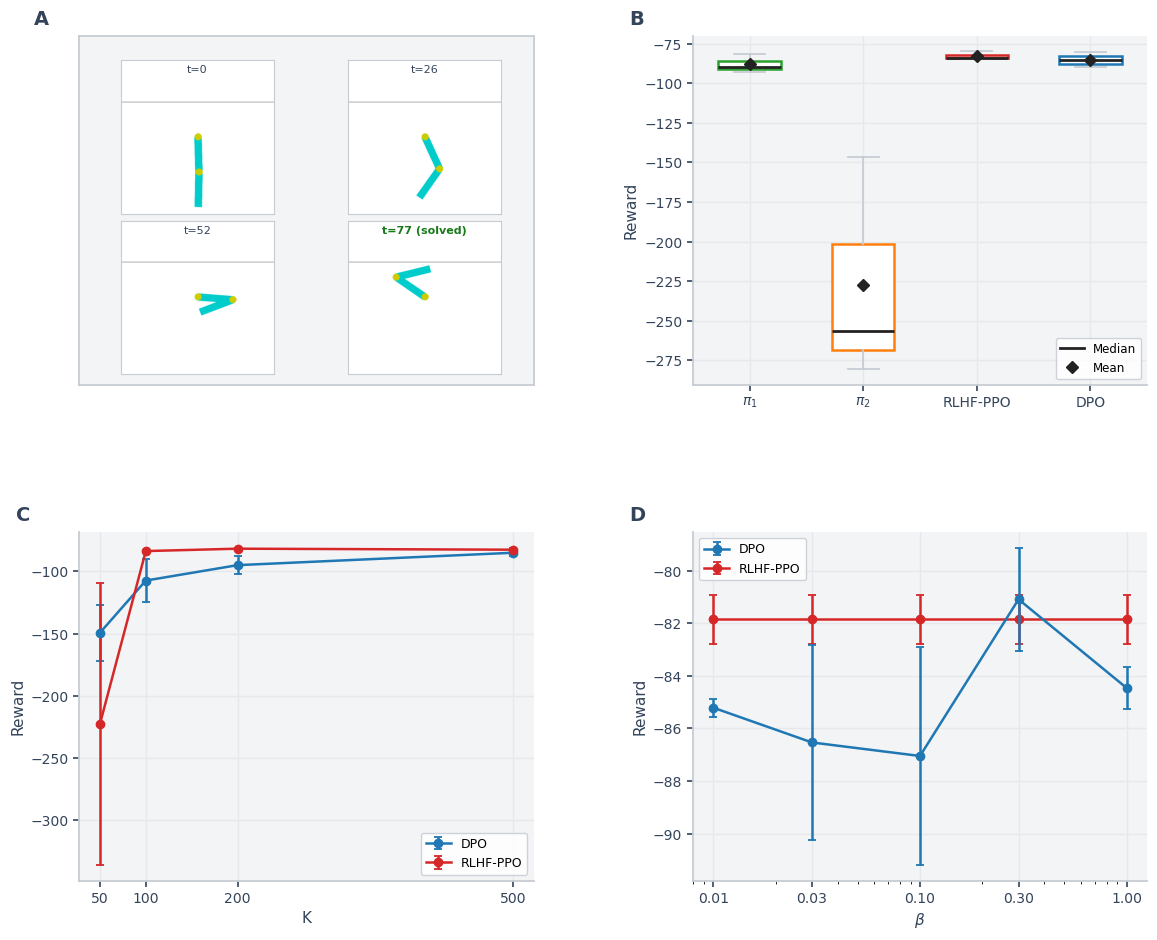

In [ ]:
plt.rcdefaults()

BG    = "#f3f4f6"; GRID  = "#e6e8eb"; SPINE = "#c7ccd3"; TEXT  = "#33435a"
C_DPO = "#1f77b4"; C_PPO = "#d62728"; C_PI1 = "#2ca02c"; C_PI2 = "#ff7f0e"

def apply_style(ax):
    ax.set_facecolor(BG); ax.grid(True, color=GRID, linewidth=1.0, zorder=0)
    ax.set_axisbelow(True)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    for sp in ["left","bottom"]:
        ax.spines[sp].set_color(SPINE); ax.spines[sp].set_linewidth(1.3)
    ax.tick_params(colors=TEXT, labelsize=10, width=1.2, length=4)
    ax.yaxis.label.set_color(TEXT); ax.xaxis.label.set_color(TEXT)

def gv(method, K):   # get per-seed values
    return np.array([r[f"{method}_mean"] for r in all_results if r["K"] == K])

# Panel A: collect episode frames (rgb_array)
_pi1 = load_checkpoint(f"{CHECKPOINT_DIR}/pi1_seed0.pth")
_env = gym.make("Acrobot-v1", render_mode="rgb_array")
_frames = None
for trial in range(60):
    obs, _ = _env.reset(seed=trial); fr = []; done, step = False, 0
    while not done and step < 500:
        fr.append(_env.render())
        with torch.no_grad():
            lgt, _ = _pi1(torch.tensor(obs, dtype=torch.float32))
        obs, _, term, trunc, _ = _env.step(torch.argmax(lgt).item())
        done = term or trunc; step += 1
    if done and term and 40 <= step <= 140:
        _frames = fr; print(f"  Episode: trial={trial}, steps={step}"); break
if _frames is None:
    for trial in range(100):
        obs, _ = _env.reset(seed=trial); fr = []; done, step = False, 0
        while not done and step < 500:
            fr.append(_env.render())
            with torch.no_grad():
                lgt, _ = _pi1(torch.tensor(obs, dtype=torch.float32))
            obs, _, term, trunc, _ = _env.step(torch.argmax(lgt).item())
            done = term or trunc; step += 1
        if done and term:
            _frames = fr; print(f"  Fallback: trial={trial}, steps={step}"); break
_env.close()
N = len(_frames)
_idx = [0, N//3, 2*N//3, N-1]
_lbs = ["t=0", f"t={_idx[1]}", f"t={_idx[2]}", f"t={N-1} (solved)"]

fig = plt.figure(figsize=(12, 9.5), facecolor="white")
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35,
                        left=0.08, right=0.97, top=0.97, bottom=0.08)

# A: real gym frames via imshow
ax_A = fig.add_subplot(gs[0,0])
ax_A.set_facecolor(BG); ax_A.set_xlim(0,1); ax_A.set_ylim(0,1)
ax_A.set_xticks([]); ax_A.set_yticks([])
for sp in ax_A.spines.values(): sp.set_color(SPINE); sp.set_linewidth(1.3)
ax_A.text(-0.10, 1.02, "A", transform=ax_A.transAxes,
          fontsize=14, fontweight="bold", color=TEXT, va="bottom")

for i, (ix, iy, iw, ih) in enumerate([(0.04,0.49,0.44,0.44),(0.54,0.49,0.44,0.44),
                                        (0.04,0.03,0.44,0.44),(0.54,0.03,0.44,0.44)]):
    ax = ax_A.inset_axes([ix, iy, iw, ih])
    ax.imshow(_frames[_idx[i]])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_color(SPINE); sp.set_linewidth(0.8)
    ax.text(0.5, 0.97, _lbs[i], transform=ax.transAxes,
            fontsize=8, ha="center", va="top",
            color="#1a7a1a" if i == 3 else TEXT,
            fontweight="bold" if i == 3 else "normal",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      alpha=0.85, edgecolor="none"))

# B: box plot K=500
ax_B = fig.add_subplot(gs[0,1]); apply_style(ax_B)
ax_B.text(-0.14,1.02,"B",transform=ax_B.transAxes,
          fontsize=14,fontweight="bold",color=TEXT,va="bottom")
_bd = [gv("pi1",500),gv("pi2",500),gv("ppo",500),gv("dpo",500)]
_bc = [C_PI1,C_PI2,C_PPO,C_DPO]
bp  = ax_B.boxplot(_bd, patch_artist=True, showfliers=False, showmeans=True, widths=0.55,
                   meanprops=dict(marker="D",markerfacecolor="#222",markeredgecolor="#222",
                                  markersize=6,zorder=5),
                   medianprops=dict(color="#222",linewidth=2.0),
                   whiskerprops=dict(color=SPINE,linewidth=1.3),
                   capprops=dict(color=SPINE,linewidth=1.3),
                   boxprops=dict(linewidth=1.3))
for patch,col in zip(bp["boxes"],_bc):
    patch.set_facecolor("white"); patch.set_edgecolor(col); patch.set_linewidth(1.8)
ax_B.set_xticks(range(1,5))
ax_B.set_xticklabels([r"$\pi_1$",r"$\pi_2$","RLHF-PPO","DPO"],fontsize=10,color=TEXT)
ax_B.set_ylabel("Reward",fontsize=11)
ax_B.legend(handles=[Line2D([0],[0],color="#222",linewidth=2.0,label="Median"),
                      Line2D([0],[0],marker="D",color="w",markerfacecolor="#222",
                             markeredgecolor="#222",markersize=6,label="Mean")],
            fontsize=8.5,framealpha=0.85,loc="lower right",edgecolor=SPINE)

# C: dataset sweep
ax_C = fig.add_subplot(gs[1,0]); apply_style(ax_C)
ax_C.text(-0.14,1.02,"C",transform=ax_C.transAxes,
          fontsize=14,fontweight="bold",color=TEXT,va="bottom")
KS = [50,100,200,500]
for method,col,lbl in [("dpo",C_DPO,"DPO"),("ppo",C_PPO,"RLHF-PPO")]:
    ms,es = [],[]
    for K in KS:
        v = gv(method,K); ms.append(v.mean()); es.append(v.std()/math.sqrt(len(v)))
    ax_C.errorbar(KS,ms,yerr=es,color=col,marker="o",markersize=6,
                  linewidth=1.8,capsize=3,capthick=1.3,label=lbl,zorder=3)
ax_C.set_xlabel("K",fontsize=11); ax_C.set_ylabel("Reward",fontsize=11)
ax_C.set_xticks(KS); ax_C.legend(fontsize=9,framealpha=0.85,edgecolor=SPINE)

# D: β sweep
ax_D = fig.add_subplot(gs[1,1]); apply_style(ax_D)
ax_D.text(-0.14,1.02,"D",transform=ax_D.transAxes,
          fontsize=14,fontweight="bold",color=TEXT,va="bottom")
bx  = sorted(beta_sweep_results.keys())
bm  = np.array([np.mean(beta_sweep_results[b]) for b in bx])
bse = np.array([np.std(beta_sweep_results[b])/math.sqrt(len(beta_sweep_results[b])) for b in bx])
ax_D.errorbar(bx,bm,yerr=bse,color=C_DPO,marker="o",markersize=6,
              linewidth=1.8,capsize=3,capthick=1.3,label="DPO",zorder=3)
# RLHF-PPO reference: same errorbar style — flat line with caps at each β x-position
pv = gv("ppo",200); pm = pv.mean(); pse = pv.std()/math.sqrt(len(pv))
ax_D.errorbar(bx,[pm]*len(bx),yerr=pse,color=C_PPO,marker="o",markersize=6,
              linewidth=1.8,capsize=3,capthick=1.3,label="RLHF-PPO",zorder=2)
ax_D.set_xscale("log"); ax_D.set_xlabel(r"$\beta$",fontsize=11)
ax_D.set_ylabel("Reward",fontsize=11)
ax_D.set_xticks(bx); ax_D.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax_D.ticklabel_format(axis="x",style="plain")
ax_D.legend(fontsize=9,framealpha=0.85,edgecolor=SPINE)

# Save
for ext in ["svg","pdf","png"]:
    fig.savefig(f"poster_combined.{ext}",dpi=180,bbox_inches="tight",
                facecolor="white",format=ext)
    print(f"Saved poster_combined.{ext}")
plt.show()

In [ ]:
import numpy as np

# R^{π_ref}: π₂ averaged over 3 seeds (K-independent, use any K)
pi2_vals = [r["pi2_mean"] for r in all_results if r["K"] == 200]
print(f"R^{{π_ref}} (π₂, 3 seeds):  {np.mean(pi2_vals):.1f}")

# PPO/RLHF and DPO at K=500, averaged over 3 seeds
ppo_500 = [r["ppo_mean"] for r in all_results if r["K"] == 500]
dpo_500 = [r["dpo_mean"] for r in all_results if r["K"] == 500]
print(f"PPO/RLHF  (K=500, 3 seeds): {np.mean(ppo_500):.1f}")
print(f"DPO       (K=500, 3 seeds): {np.mean(dpo_500):.1f}")

# Optional: averaged over all K values
ppo_all = [r["ppo_mean"] for r in all_results]
dpo_all = [r["dpo_mean"] for r in all_results]
print(f"\nPPO/RLHF  (all K, 12 runs): {np.mean(ppo_all):.1f}")
print(f"DPO       (all K, 12 runs): {np.mean(dpo_all):.1f}")

R^{π_ref} (π₂, 3 seeds):  -210.8
PPO/RLHF  (K=500, 3 seeds): -82.7
DPO       (K=500, 3 seeds): -85.1

PPO/RLHF  (all K, 12 runs): -117.8
DPO       (all K, 12 runs): -109.3
